In [1]:
import pickle

with open("/scr/vidit/label_free_benchmark/iclr_model/embeddings.pkl", 'rb') as f:
    chammi_embeddings = pickle.load(f)
print(f"Total embeddings loaded: {len(chammi_embeddings)}")

with open("/scr/vidit/label_free_benchmark/dinov2/embeddings.pkl", 'rb') as f:
    dinov2_embeddings = pickle.load(f)
print(f"Total embeddings loaded: {len(dinov2_embeddings)}")

Total embeddings loaded: 130560
Total embeddings loaded: 130560


In [3]:
# Cross-Dataset Logistic Regression Classification
# Vision Transformer Embeddings Analysis

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 6)

In [24]:
# Cross-Dataset Logistic Regression Classification
# Vision Transformer Embeddings Analysis

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 6)

## Step 1: Load and Inspect Data

# Assuming your embeddings list is already loaded
# embeddings = [...]  # Your data here

def inspect_data(embeddings):
    """Quick inspection of the data structure"""
    print("Data Structure Inspection:")
    print("-" * 60)
    print(f"Total samples: {len(embeddings)}")
    print(f"\nFirst sample structure:")
    sample = embeddings[0]
    print(f"  Keys: {list(sample.keys())}")
    print(f"  Metadata keys: {list(sample['metadata'].keys())}")
    print(f"  Embedding shape: {len(sample['embedding'])}")
    
    # Count by dataset
    swiss_count = sum(1 for item in embeddings if item['metadata']['label'] == 'Swiss')
    canadian_count = sum(1 for item in embeddings if item['metadata']['label'] == 'Canadian')
    print(f"\nDataset distribution:")
    print(f"  Swiss: {swiss_count} samples")
    print(f"  Canadian: {canadian_count} samples")
    
    # Count by classifier
    classifiers = {}
    for item in embeddings:
        clf_name = item['metadata']['classifier_name']
        classifiers[clf_name] = classifiers.get(clf_name, 0) + 1
    
    print(f"\nClass distribution:")
    for clf_name, count in sorted(classifiers.items()):
        print(f"  {clf_name}: {count} samples")

# Uncomment to inspect your data
# inspect_data(embeddings)


## Step 2: Data Extraction Functions

def extract_data(embeddings, dataset_label, exclude_classes=None, handle_nan='zero'):
    """
    Extract embeddings and labels for a specific dataset
    
    Parameters:
    -----------
    embeddings : list
        List containing multi-level dictionaries with metadata and embedding
    dataset_label : str
        Either 'Swiss' or 'Canadian'
    exclude_classes : list, optional
        List of class names to exclude (e.g., ['Undecidable'])
    
    Returns:
    --------
    X : numpy array
        Feature matrix (embeddings)
    y : numpy array
        Target labels (classifier_name)
    """
    if exclude_classes is None:
        exclude_classes = []
    
    X = []
    y = []
    nan_count = 0
    
    for item in embeddings:
        classifier_name = item['metadata']['classifier_name']
        
        # Skip excluded classes
        if classifier_name in exclude_classes:
            continue
            
        if item['metadata']['label'] == dataset_label:
            embedding = np.array(item['embedding'])
            # Check for NaN values
            if np.any(np.isnan(embedding)):
                nan_count += 1
                if handle_nan == 'remove':
                    continue  # Skip this sample
                elif handle_nan == 'zero':
                    embedding = np.nan_to_num(embedding, nan=0.0)
                elif handle_nan == 'mean':
                    # Replace NaN with mean of non-NaN values in this embedding
                    embedding = np.where(np.isnan(embedding), 
                                        np.nanmean(embedding), 
                                        embedding)
            X.append(embedding)
            y.append(classifier_name)
    
    return np.array(X), np.array(y)


def get_class_distribution(y, label_encoder):
    """Get distribution of classes"""
    unique, counts = np.unique(y, return_counts=True)
    distribution = dict(zip(unique, counts))
    return distribution


## Step 3: Model Training and Evaluation

def train_logistic_regression(X_train, y_train, X_test, y_test, label_encoder, 
                               model_params=None):
    """
    Train and evaluate logistic regression model
    
    Parameters:
    -----------
    X_train, y_train : Training data
    X_test, y_test : Test data
    label_encoder : Fitted LabelEncoder
    model_params : dict, optional model parameters
    
    Returns:
    --------
    Dictionary with predictions, accuracy, confusion matrix, and model
    """
    if model_params is None:
        model_params = {
            'max_iter': 1000,
            'random_state': 42,
            'multi_class': 'multinomial',
            'solver': 'lbfgs',
            'C': 1.0
        }
    
    # Encode labels
    y_train_encoded = label_encoder.transform(y_train)
    y_test_encoded = label_encoder.transform(y_test)
    
    # Train model
    print("  Training model...")
    clf = LogisticRegression(**model_params)
    clf.fit(X_train, y_train_encoded)
    
    # Predict
    print("  Making predictions...")
    y_pred = clf.predict(X_test)
    y_pred_proba = clf.predict_proba(X_test)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test_encoded, y_pred)
    cm = confusion_matrix(y_test_encoded, y_pred, normalize='true')
    
    # Get classification report
    report = classification_report(
        y_test_encoded, 
        y_pred, 
        target_names=label_encoder.classes_,
        output_dict=True
    )
    
    return {
        'model': clf,
        'predictions': y_pred,
        'predictions_proba': y_pred_proba,
        'accuracy': accuracy,
        'confusion_matrix': cm,
        'classification_report': report
    }


## Step 4: Visualization Functions

def plot_confusion_matrices(cm1, cm2, class_names, acc1, acc2, 
                            title1="Train on Canadian set", 
                            title2="Train on Swiss set"):
    """Plot two confusion matrices side by side matching the reference image"""
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Plot 1
    sns.heatmap(
        cm1,
        annot=True,
        fmt='.2f',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names,
        ax=axes[0],
        cbar_kws={'label': ''},
        vmin=0,
        vmax=1,
        square=False
    )
    axes[0].set_title(f'A          {title1}\nValidate on Swiss set (acc.={acc1:.1%})', 
                      fontsize=12, fontweight='bold', loc='left')
    axes[0].set_xlabel('Deep learning prediction', fontsize=11)
    axes[0].set_ylabel('Cyprinid shape annotation', fontsize=11)
    axes[0].tick_params(axis='x', rotation=45, labelsize=9)
    axes[0].tick_params(axis='y', rotation=0, labelsize=9)
    
    # Plot 2
    sns.heatmap(
        cm2,
        annot=True,
        fmt='.2f',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names,
        ax=axes[1],
        cbar_kws={'label': ''},
        vmin=0,
        vmax=1,
        square=False
    )
    axes[1].set_title(f'B          {title2}\nValidate on Canadian set (acc.={acc2:.1%})', 
                      fontsize=12, fontweight='bold', loc='left')
    axes[1].set_xlabel('Deep learning prediction', fontsize=11)
    axes[1].set_ylabel('Cyprinid shape annotation', fontsize=11)
    axes[1].tick_params(axis='x', rotation=45, labelsize=9)
    axes[1].tick_params(axis='y', rotation=0, labelsize=9)
    
    plt.tight_layout()
    plt.show()


def plot_per_class_performance(report1, report2, class_names):
    """Plot per-class F1 scores for both experiments"""
    
    f1_scores_1 = [report1[cls]['f1-score'] for cls in class_names]
    f1_scores_2 = [report2[cls]['f1-score'] for cls in class_names]
    
    x = np.arange(len(class_names))
    width = 0.35
    
    fig, ax = plt.subplots(figsize=(12, 6))
    bars1 = ax.bar(x - width/2, f1_scores_1, width, label='Train on Canadian', alpha=0.8)
    bars2 = ax.bar(x + width/2, f1_scores_2, width, label='Train on Swiss', alpha=0.8)
    
    ax.set_xlabel('Class', fontsize=12)
    ax.set_ylabel('F1-Score', fontsize=12)
    ax.set_title('Per-Class F1-Scores: Cross-Dataset Performance', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(class_names, rotation=45, ha='right')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim([0, 1])
    
    plt.tight_layout()
    plt.show()


## Step 5: Main Analysis Pipeline

def run_cross_dataset_classification(embeddings, model_params=None, exclude_classes=None):
    """
    Complete pipeline for cross-dataset classification
    
    Parameters:
    -----------
    embeddings : list
        Your embeddings data structure
    model_params : dict, optional
        Custom parameters for LogisticRegression
    exclude_classes : list, optional
        List of class names to exclude from training/testing
        Default: ['Undecidable'] to remove uncertain classifications
    
    Returns:
    --------
    results : dict
        Complete results including models, metrics, and visualizations
    """
    
    # Set default excluded classes
    if exclude_classes is None:
        exclude_classes = ['Undecidable']
    
    print("="*70)
    print("CROSS-DATASET LOGISTIC REGRESSION CLASSIFICATION")
    print("Vision Transformer Embeddings (384-dim)")
    print("="*70)
    
    # Show excluded classes if any
    if exclude_classes:
        print(f"\n⚠️  Excluding classes: {', '.join(exclude_classes)}")
    
    # Extract data
    print("\n[Step 1/6] Extracting data from both datasets...")
    X_swiss, y_swiss = extract_data(embeddings, 'Swiss', exclude_classes=exclude_classes)
    X_canadian, y_canadian = extract_data(embeddings, 'Canadian', exclude_classes=exclude_classes)
    
    print(f"  ✓ Swiss dataset: {X_swiss.shape[0]} samples × {X_swiss.shape[1]} features")
    print(f"  ✓ Canadian dataset: {X_canadian.shape[0]} samples × {X_canadian.shape[1]} features")
    
    # Prepare label encoder
    print("\n[Step 2/6] Preparing label encoder...")
    all_classes = np.unique(np.concatenate([y_swiss, y_canadian]))
    label_encoder = LabelEncoder()
    label_encoder.fit(all_classes)
    
    print(f"  ✓ Number of classes: {len(all_classes)}")
    print(f"  ✓ Classes: {', '.join(all_classes)}")
    
    # Experiment 1: Train on Canadian, Test on Swiss
    print("\n[Step 3/6] Experiment 1: Train on Canadian → Validate on Swiss")
    results_1 = train_logistic_regression(
        X_canadian, y_canadian,
        X_swiss, y_swiss,
        label_encoder,
        model_params
    )
    print(f"  ✓ Accuracy: {results_1['accuracy']:.4f} ({results_1['accuracy']*100:.2f}%)")
    
    # Experiment 2: Train on Swiss, Test on Canadian
    print("\n[Step 4/6] Experiment 2: Train on Swiss → Validate on Canadian")
    results_2 = train_logistic_regression(
        X_swiss, y_swiss,
        X_canadian, y_canadian,
        label_encoder,
        model_params
    )
    print(f"  ✓ Accuracy: {results_2['accuracy']:.4f} ({results_2['accuracy']*100:.2f}%)")
    
    # Create visualizations
    print("\n[Step 5/6] Creating confusion matrix visualization...")
    plot_confusion_matrices(
        results_1['confusion_matrix'],
        results_2['confusion_matrix'],
        list(all_classes),
        results_1['accuracy'],
        results_2['accuracy']
    )
    
    print("\n[Step 6/6] Creating per-class performance comparison...")
    plot_per_class_performance(
        results_1['classification_report'],
        results_2['classification_report'],
        list(all_classes)
    )
    
    # Summary
    print("\n" + "="*70)
    print("SUMMARY")
    print("="*70)
    print(f"\nExperiment 1 (Train Canadian → Test Swiss):")
    print(f"  Accuracy: {results_1['accuracy']:.1%}")
    print(f"\nExperiment 2 (Train Swiss → Test Canadian):")
    print(f"  Accuracy: {results_2['accuracy']:.1%}")
    print(f"\nAverage Cross-Dataset Accuracy: {(results_1['accuracy'] + results_2['accuracy'])/2:.1%}")
    print("\n" + "="*70)
    
    return {
        'experiment_1': results_1,
        'experiment_2': results_2,
        'label_encoder': label_encoder,
        'class_names': list(all_classes),
        'X_swiss': X_swiss,
        'y_swiss': y_swiss,
        'X_canadian': X_canadian,
        'y_canadian': y_canadian
    }

CROSS-DATASET LOGISTIC REGRESSION CLASSIFICATION
Vision Transformer Embeddings (384-dim)

⚠️  Excluding classes: Undecidable

[Step 1/6] Extracting data from both datasets...
  ✓ Swiss dataset: 76564 samples × 384 features
  ✓ Canadian dataset: 46712 samples × 384 features

[Step 2/6] Preparing label encoder...
  ✓ Number of classes: 7
  ✓ Classes: CrenatedDisc, CrenatedDiscoid, CrenatedSphere, CrenatedSpheroid, Side, SmoothDisc, SmoothSphere

[Step 3/6] Experiment 1: Train on Canadian → Validate on Swiss
  Training model...
  Making predictions...
  ✓ Accuracy: 0.6840 (68.40%)

[Step 4/6] Experiment 2: Train on Swiss → Validate on Canadian
  Training model...
  Making predictions...
  ✓ Accuracy: 0.6502 (65.02%)

[Step 5/6] Creating confusion matrix visualization...


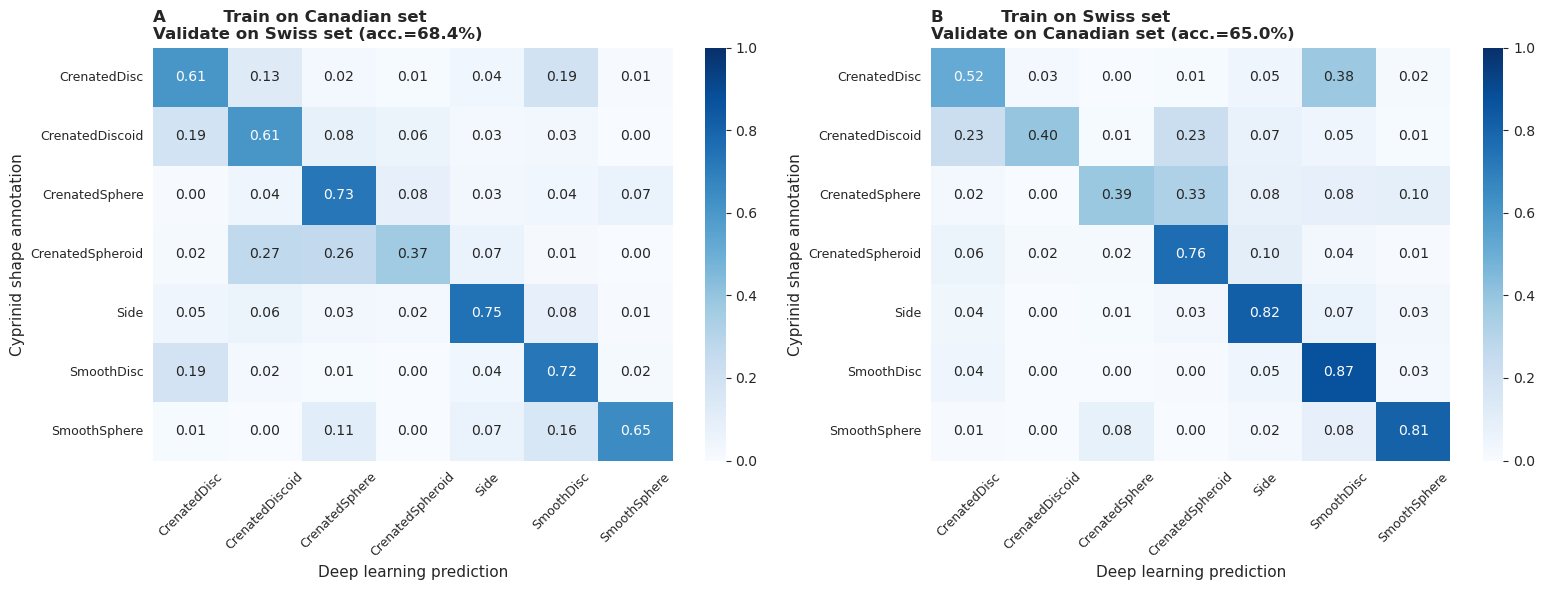


[Step 6/6] Creating per-class performance comparison...


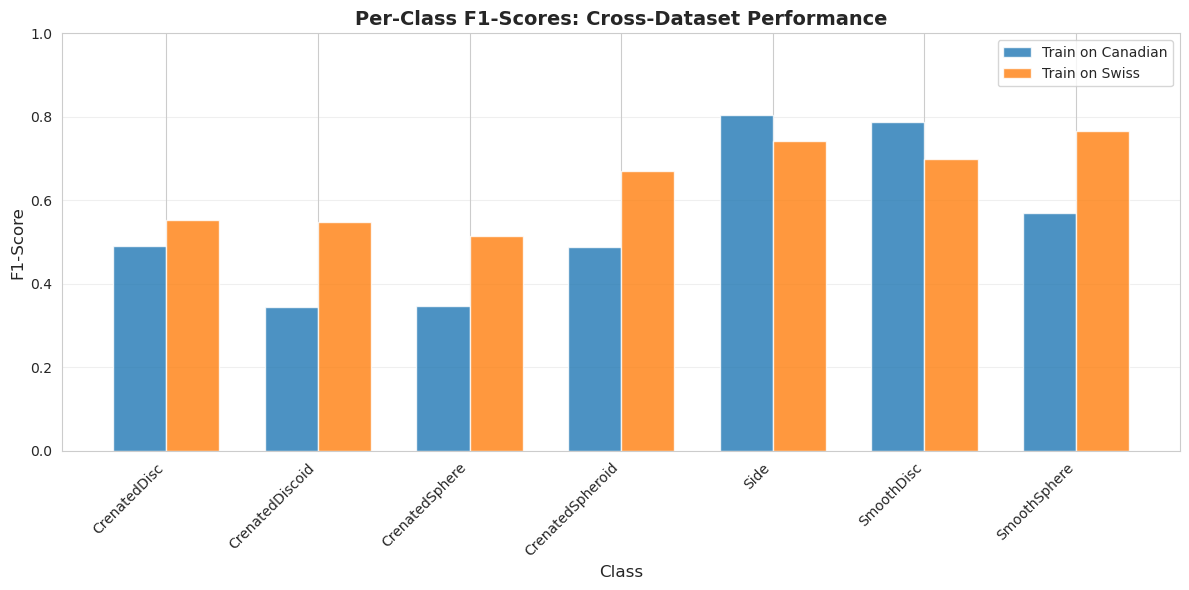


SUMMARY

Experiment 1 (Train Canadian → Test Swiss):
  Accuracy: 68.4%

Experiment 2 (Train Swiss → Test Canadian):
  Accuracy: 65.0%

Average Cross-Dataset Accuracy: 66.7%



(0.683950681782561, 0.6502183593081007)

In [25]:
results = run_cross_dataset_classification(embeddings=chammi_embeddings, exclude_classes=["Undecidable"])
results['experiment_1']['accuracy'], results['experiment_2']['accuracy']

CROSS-DATASET LOGISTIC REGRESSION CLASSIFICATION
Vision Transformer Embeddings (384-dim)

⚠️  Excluding classes: Undecidable

[Step 1/6] Extracting data from both datasets...
  ✓ Swiss dataset: 76571 samples × 384 features
  ✓ Canadian dataset: 46702 samples × 384 features

[Step 2/6] Preparing label encoder...
  ✓ Number of classes: 7
  ✓ Classes: CrenatedDisc, CrenatedDiscoid, CrenatedSphere, CrenatedSpheroid, Side, SmoothDisc, SmoothSphere

[Step 3/6] Experiment 1: Train on Canadian → Validate on Swiss
  Training model...
  Making predictions...
  ✓ Accuracy: 0.5944 (59.44%)

[Step 4/6] Experiment 2: Train on Swiss → Validate on Canadian
  Training model...
  Making predictions...
  ✓ Accuracy: 0.5537 (55.37%)

[Step 5/6] Creating confusion matrix visualization...


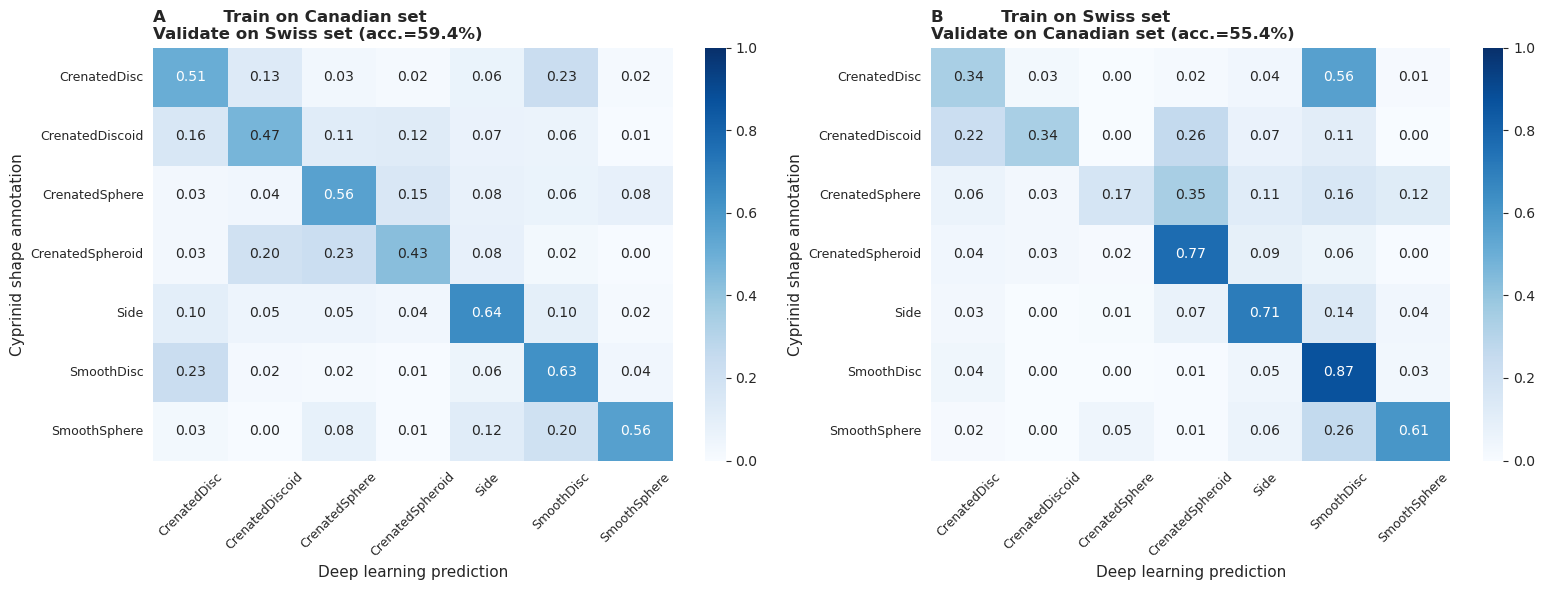


[Step 6/6] Creating per-class performance comparison...


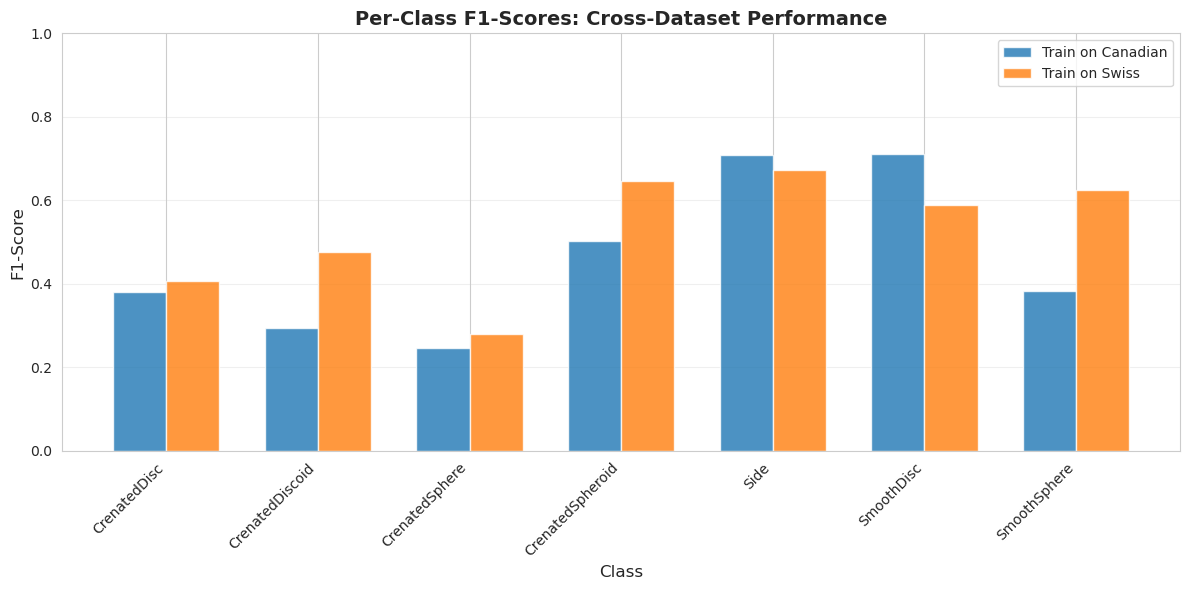


SUMMARY

Experiment 1 (Train Canadian → Test Swiss):
  Accuracy: 59.4%

Experiment 2 (Train Swiss → Test Canadian):
  Accuracy: 55.4%

Average Cross-Dataset Accuracy: 57.4%



(0.5943503415131055, 0.5537021969080553)

In [26]:
results = run_cross_dataset_classification(embeddings=dinov2_embeddings, exclude_classes=["Undecidable"])
results['experiment_1']['accuracy'], results['experiment_2']['accuracy']